# 03 — Who are we actually predicting for?

This is the notebook that matters most, and its conclusion is not obvious.

We're going to make a design choice that **makes our numbers look worse**, and
then demonstrate — with a real model, not an argument — that the better-looking
alternative is measuring something worthless.

If you read only one notebook in this project, read this one.


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "src" / "oulad").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from oulad import load, viz
from oulad import labels as lab

viz.use_project_style()
pd.set_option("display.width", 100)

tables = load.load_all(verbose=False)
labels = lab.build_labels(tables["studentInfo"], tables["studentRegistration"])
KEY = lab.KEY
CUTOFF = 28
print(f"{len(labels):,} enrolments loaded")

  note: 9 enrolments have an unregistration date but a non-Withdrawn outcome.
32,593 enrolments loaded


## The cutoff

An early-warning system has to fire at a specific moment. Call it the **cutoff**
— we'll use **day 28**, four weeks in.

The rule: the model may only use information dated on or before day 28. Anything
later hasn't happened yet in real life, so using it would be cheating. (There's
a name for that kind of cheating — **leakage** — and it's the subject of
`docs/02-leakage.md`.)

Now recall the column from notebook 01: `date_unregistration`, the day a student
dropped out. Let's look at *when* people drop out.

In [2]:
withdrawn = labels[labels["withdrew"] == 1]

print(f"total withdrawals: {len(withdrawn):,}\n")
print("Day of withdrawal, by percentile:")
for p in [0.10, 0.25, 0.50, 0.75, 0.90]:
    print(f"  {int(p*100):>3d}th  day {withdrawn['date_unregistration'].quantile(p):>7.0f}")

pre = (withdrawn["date_unregistration"] < 0).sum()
print(f"\nbefore day 0: {pre:,} ({100*pre/len(withdrawn):.1f}%) "
      "-- left before teaching began")

total withdrawals: 10,156

Day of withdrawal, by percentile:
   10th  day     -38
   25th  day      -2
   50th  day      27
   75th  day     109
   90th  day     170

before day 0: 2,676 (26.3%) -- left before teaching began


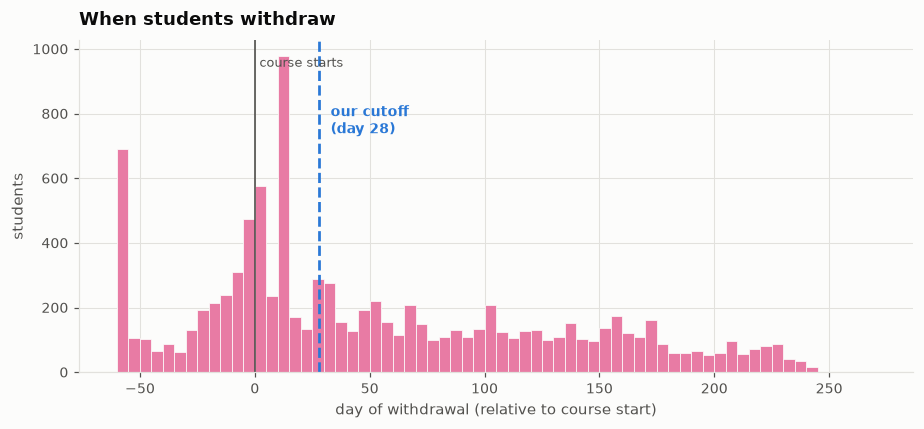

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.0))
d = withdrawn["date_unregistration"].clip(-60, 270)
ax.hist(d, bins=66, color=viz.MAGENTA, edgecolor=viz.SURFACE, linewidth=0.5)
ax.axvline(0, color=viz.INK_SOFT, linewidth=1.1)
ax.annotate("course starts", xy=(2, ax.get_ylim()[1]*0.92), fontsize=8.5,
            color=viz.INK_SOFT)
ax.axvline(CUTOFF, color=viz.BLUE, linewidth=1.8, linestyle="--")
ax.annotate(f"our cutoff\n(day {CUTOFF})", xy=(CUTOFF + 5, ax.get_ylim()[1]*0.72),
            fontsize=9, color=viz.BLUE, weight="bold")
ax.set_xlabel("day of withdrawal (relative to course start)")
ax.set_ylabel("students")
ax.set_title("When students withdraw")
viz.show(fig)

Two things to notice.

**A big spike before and around day 0.** Thousands register and leave before
teaching starts, or in the opening days.

**But a long tail to the right.** The 75th percentile is day 109 — a quarter of
withdrawals happen past the halfway mark. Dropout is *not* purely an
early-course phenomenon, which is easy to assume and wrong.

## The two groups

Everything to the **left** of the blue dashed line has already happened by the
time we make our prediction. So on day 28, our 32,593 enrolments split in two.

In [4]:
already_left = (
    labels["date_unregistration"].notna()
    & (labels["date_unregistration"] <= CUTOFF)
)

print(f"Group A -- still enrolled on day {CUTOFF}: {(~already_left).sum():>7,}")
print(f"Group B -- already gone           : {already_left.sum():>7,}")
print()
print(f"Group B is {100*already_left.mean():.1f}% of all enrolments.")

Group A -- still enrolled on day 28:  27,538
Group B -- already gone           :   5,055

Group B is 15.5% of all enrolments.


**The question: should the model make predictions about Group B?**

Your instinct says yes. More data is better; don't throw away 5,055 rows.

That instinct is wrong here, and the rest of this notebook shows why — first the
argument, then the measurement.

### The argument

**It isn't a prediction.** Group B's outcomes are already recorded. The
university can look them up instantly. "Predicting" them is bookkeeping.

**And they poison what the model learns.** A student who withdrew on day 10
*stopped clicking on day 10*. From day 11 to day 28 their record is silence.

A model doesn't know what any column means. It searches for whatever separates
the two outcomes most cleanly. So it will find:

> "No clicks in the last two weeks → won't pass"

— which is right essentially every time, for Group B. It isn't detecting risk.
It's detecting *absence*, in people who are absent because they already left.

Let's check that claim before relying on it.

## Building some quick features

To test this we need something to feed a model. Four simple numbers per student,
using only clicks from day 28 or earlier.

(This is a throwaway version. Phase 2 builds the real feature set properly.)

In [5]:
clicks = tables["studentVle"]
early = clicks[clicks["date"] <= CUTOFF]
print(f"clickstream rows on or before day {CUTOFF}: {len(early):,} "
      f"(of {len(clicks):,} total)")

agg = (
    early.groupby(KEY)
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        last_active=("date", "max"),
    )
    .reset_index()
)
agg.head()

clickstream rows on or before day 28: 2,847,851 (of 10,655,280 total)


,id_student,code_module,code_presentation,total_clicks,active_days,last_active
0,6516,AAA,2014J,826,28,28
1,8462,DDD,2013J,375,20,28
2,8462,DDD,2014J,10,1,10
3,11391,AAA,2013J,401,8,18
4,23629,BBB,2013B,53,6,21


In [6]:
def make_features(population):
    """Attach the four features to a set of enrolments."""
    df = population.merge(agg, on=KEY, how="left")

    # No clickstream rows at all means the student never showed up.
    df["total_clicks"] = df["total_clicks"].fillna(0)
    df["active_days"] = df["active_days"].fillna(0)
    # Treat "never active" as last seen before the course began.
    df["last_active"] = df["last_active"].fillna(-1)

    df["days_since_active"] = CUTOFF - df["last_active"]
    df["clicks_per_active_day"] = np.where(
        df["active_days"] > 0, df["total_clicks"] / df["active_days"], 0.0
    )
    return df


FEATURES = ["total_clicks", "active_days", "days_since_active", "clicks_per_active_day"]

naive_pop = make_features(labels)                                    # everyone
correct_pop = make_features(labels.loc[~already_left])               # Group A only

print(f"naive framing  : {len(naive_pop):,} enrolments")
print(f"correct framing: {len(correct_pop):,} enrolments")

naive framing  : 32,593 enrolments
correct framing: 27,538 enrolments


### First, is the "silence" claim true?

Before modelling, just look at `days_since_active` for the two groups.

In [7]:
left = naive_pop[already_left.to_numpy()]
stayed = naive_pop[~already_left.to_numpy()]

print("Days since last click, at day 28")
print(f"  Group B (already gone)  median {left['days_since_active'].median():>5.0f}")
print(f"  Group A (still enrolled) median {stayed['days_since_active'].median():>5.0f}")
print()
print(f"  Group B with 14+ silent days: {100*(left['days_since_active']>=14).mean():>5.1f}%")
print(f"  Group A with 14+ silent days: {100*(stayed['days_since_active']>=14).mean():>5.1f}%")

Days since last click, at day 28
  Group B (already gone)  median    29
  Group A (still enrolled) median     2

  Group B with 14+ silent days:  82.8%
  Group A with 14+ silent days:   9.8%


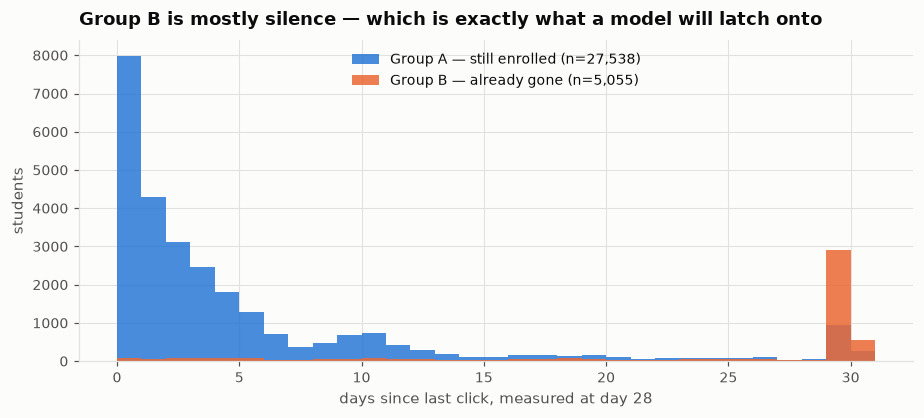

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 3.9))
bins = np.arange(0, 32, 1)
ax.hist(stayed["days_since_active"].clip(0, 30), bins=bins, color=viz.NOT_AT_RISK,
        alpha=0.85, label=f"Group A — still enrolled (n={len(stayed):,})")
ax.hist(left["days_since_active"].clip(0, 30), bins=bins, color=viz.AT_RISK,
        alpha=0.85, label=f"Group B — already gone (n={len(left):,})")
ax.set_xlabel("days since last click, measured at day 28")
ax.set_ylabel("students")
ax.set_title("Group B is mostly silence — which is exactly what a model will latch onto")
ax.legend(loc="upper center")
viz.show(fig)

There it is. Group B piles up at the right-hand end — long stretches of no
activity — while Group A clusters at the left.

That separation is real, it's enormous, and it's **useless**, because it only
tells you something you already knew about people who have already left.

## Now measure the damage

We'll fit the same model, with the same features and the same validation scheme,
on both framings. The *only* difference is who is in the population.

Some machinery, explained:

- **Logistic regression** — despite the name, a classification model. It fits a
  weighted sum of the features and squashes the result to a number between 0 and
  1. Its virtue here is that the weights are readable.
- **`StandardScaler`** — puts every feature on a comparable scale, so a
  coefficient of 2 on one feature means the same as a coefficient of 2 on
  another.
- **`Pipeline`** — chains the scaler and the model into one object. This matters:
  it makes the scaler get fitted *inside* each validation fold rather than on all
  the data first. Fitting it beforehand would let the held-out data influence
  training — a subtle leak.
- **`GroupKFold`** — splits into 5 parts, keeping all of a student's enrolments
  in the same part, for the reason covered in notebook 02.
- **`average_precision_score`** — this is **PR-AUC**, our headline metric. It
  summarises how well the model *ranks* students, across all possible
  thresholds, focusing on the positive class.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def evaluate(df, framing):
    X = df[FEATURES].to_numpy()
    y = df["at_risk"].to_numpy()
    groups = df["id_student"].to_numpy()

    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ])

    # Predict each row using folds it was not part of training.
    proba = cross_val_predict(
        pipe, X, y, groups=groups, cv=GroupKFold(n_splits=5),
        method="predict_proba",
    )[:, 1]

    base = y.mean()
    pr_auc = average_precision_score(y, proba)
    return {
        "framing": framing,
        "n": len(df),
        "base_rate": round(base, 3),
        "PR_AUC": round(pr_auc, 3),
        "lift_over_base": round(pr_auc / base, 2),
    }


results = pd.DataFrame([
    evaluate(naive_pop, "naive — everyone"),
    evaluate(correct_pop, "correct — still enrolled"),
])
results

,framing,n,base_rate,PR_AUC,lift_over_base
0,naive — everyone,32593,0.528,0.790,1.50
1,correct — still enrolled,27538,0.441,0.613,1.39


## Reading this table — and a trap inside it

The naive framing scores a **higher PR-AUC**. If you were chasing a number,
you'd pick it and feel good.

But look at the `base_rate` column, and here's a genuinely important subtlety:

> **PR-AUC's floor is the base rate.** A model that ranks at random scores
> roughly the base rate. So you cannot compare PR-AUC across two populations
> with different base rates — part of any difference is just the floor moving.

The naive population has a base rate of 0.528; the correct one 0.441. So some of
the naive framing's apparent advantage is free, and nothing to do with skill.

`lift_over_base` divides PR-AUC by the base rate, which is a fairer comparison:
how many times better than chance is this model?

Compare the two lift figures. The naive framing's advantage shrinks
substantially once you account for its easier starting point — and what's left
is the fake part, earned by correctly ranking people who had already gone.

**Generalisable lesson:** whenever you compare a metric across two different
datasets, check whether the metric's baseline is the same in both. A lot of
apparent improvements are baseline movements in disguise.

## What is the naive model actually using?

Coefficients tell us what the model leans on. Because the features were scaled,
they're directly comparable: bigger absolute value means more influence.

In [10]:
def coefficients(df, framing):
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ])
    pipe.fit(df[FEATURES], df["at_risk"])
    return pd.Series(pipe["model"].coef_[0], index=FEATURES, name=framing).round(3)


coefs = pd.concat([
    coefficients(naive_pop, "naive"),
    coefficients(correct_pop, "correct"),
], axis=1)
coefs

,naive,correct
total_clicks,-0.066,-0.105
active_days,-0.351,-0.364
days_since_active,0.880,0.301
clicks_per_active_day,-0.062,-0.028


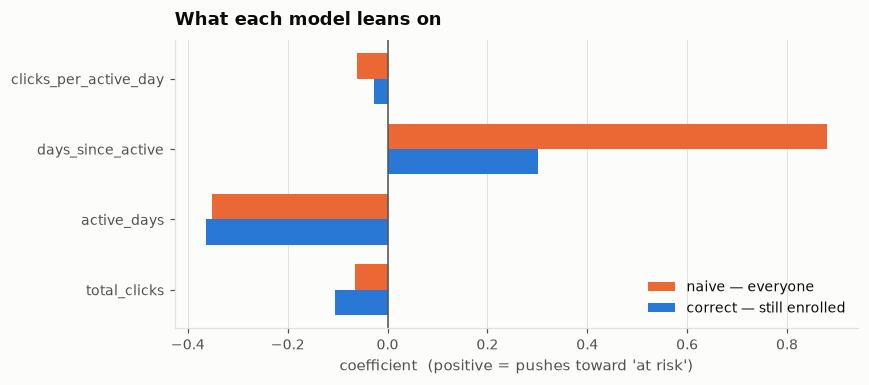

In [11]:
fig, ax = plt.subplots(figsize=(8.0, 3.6))
y = np.arange(len(FEATURES))
h = 0.36
ax.barh(y + h/2, coefs["naive"], height=h, color=viz.AT_RISK, label="naive — everyone")
ax.barh(y - h/2, coefs["correct"], height=h, color=viz.NOT_AT_RISK,
        label="correct — still enrolled")
ax.set_yticks(y, FEATURES)
ax.axvline(0, color=viz.INK_SOFT, linewidth=1.0)
ax.set_xlabel("coefficient  (positive = pushes toward 'at risk')")
ax.set_title("What each model leans on")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
viz.show(fig)

`days_since_active` is the dominant feature in the naive model — a large
positive weight, meaning "the longer since they last clicked, the more at risk".

Which is true, and which is mostly just re-reading Group B's withdrawal from
their empty clickstream.

In the correct framing that feature's influence drops and the model has to
spread its attention across actual engagement — volume and consistency.

That's the whole point. The naive model found the easy shortcut and took it.
Remove the shortcut and it's forced to learn something that might actually
transfer to a student you can still help.

## The cost, and what you get for it

Applying this rule across candidate cutoffs:

In [12]:
summary = lab.cutoff_population_summary(labels, [7, 14, 28, 56, 84])
summary.round(3)

,cutoff_day,n_eligible,pct_of_all,n_already_left,base_rate_at_risk,base_rate_withdraw
0,7,29178,89.522,3415,0.473,0.231
1,14,28119,86.273,4474,0.453,0.202
2,28,27538,84.491,5055,0.441,0.186
3,56,26522,81.373,6071,0.420,0.154
4,84,25724,78.925,6869,0.402,0.128


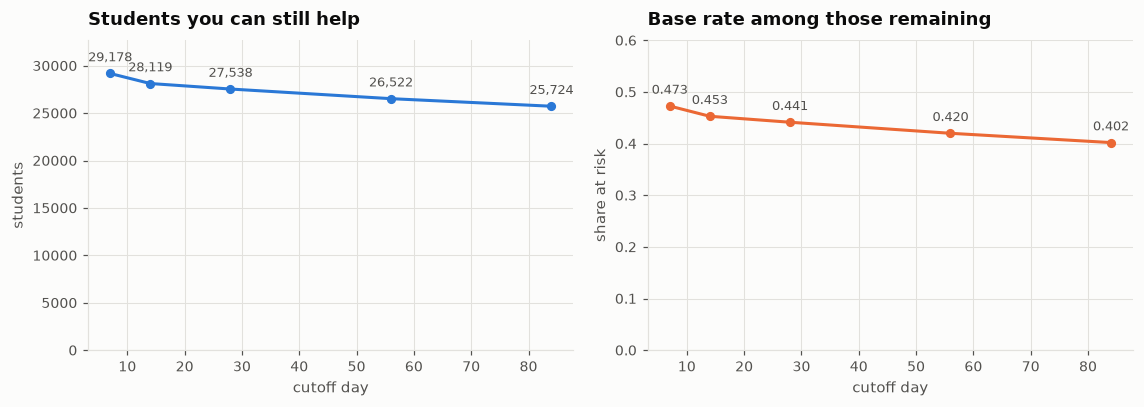

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

ax1.plot(summary["cutoff_day"], summary["n_eligible"], marker="o",
         color=viz.NOT_AT_RISK)
ax1.set_xlabel("cutoff day")
ax1.set_ylabel("students")
ax1.set_title("Students you can still help")
ax1.set_ylim(0, summary["n_eligible"].max() * 1.12)
for _, r in summary.iterrows():
    ax1.annotate(f"{r.n_eligible:,.0f}", xy=(r.cutoff_day, r.n_eligible),
                 xytext=(0, 8), textcoords="offset points",
                 fontsize=8.5, ha="center", color=viz.INK_SOFT)

ax2.plot(summary["cutoff_day"], summary["base_rate_at_risk"], marker="o",
         color=viz.AT_RISK)
ax2.set_xlabel("cutoff day")
ax2.set_ylabel("share at risk")
ax2.set_title("Base rate among those remaining")
ax2.set_ylim(0, 0.6)
for _, r in summary.iterrows():
    ax2.annotate(f"{r.base_rate_at_risk:.3f}", xy=(r.cutoff_day, r.base_rate_at_risk),
                 xytext=(0, 8), textcoords="offset points",
                 fontsize=8.5, ha="center", color=viz.INK_SOFT)

viz.show(fig)

Two panels, not one chart with two y-axes. Putting two different scales on a
single plot invites the reader to see a relationship in how the lines cross,
which is an artefact of where you happened to put the axes. Two panels, one
scale each.

Both lines fall as the cutoff moves later. That is the trade-off the whole
project is about:

| Waiting longer | Effect |
|---|---|
| More days of behaviour per student | Prediction gets **easier** |
| More students already gone | **Fewer people left to help** |
| Those remaining are the ambiguous ones | Prediction gets **harder** |
| Less course left | **Less time to act** |

Only the first helps. Finding where these balance is the headline result of the
project — and it only exists as a question because we defined the population
correctly. Under the naive framing the answer is just "later is better", which
is both boring and wrong.

## What to take away

1. **At any cutoff, some students have already withdrawn.** At day 28 it's 5,055
   — 15.5% of enrolments.
2. **Including them inflates your score and corrupts what the model learns.**
   They're weeks of silence, and a model will happily build its whole strategy
   around that.
3. **Measured, not assumed:** we fit the same model both ways and watched
   `days_since_active` dominate the naive version.
4. **PR-AUC can't be compared across populations with different base rates.**
   Its floor moves. Compare lift over baseline instead.
5. **The fix makes results look worse.** That's the signature of a real fix. A
   change that improves your headline number deserves suspicion, not celebration.

The rule is `labels.modelling_population(labels, cutoff_day)`, and it applies
this filter by default.

Next: [`04-exploring-behaviour.ipynb`](04-exploring-behaviour.ipynb) — now that
we know who we're predicting for, what does their behaviour actually look
like?